In [1]:
# MSIT 3103 — Environment setup (run this cell once per machine)
# Installs/updates the required packages into the same Python used by this notebook

import sys
print(f"Using Python {sys.version.split()[0]}")

# Install required packages into the current notebook environment
%pip install -qU numpy matplotlib scikit-learn torch torchvision


# Verify versions
import numpy as np, matplotlib, sklearn
print("numpy       :", np.__version__)
print("matplotlib  :", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)
print("✅ Setup complete!")


Using Python 3.10.11
Note: you may need to restart the kernel to use updated packages.
numpy       : 2.2.6
matplotlib  : 3.10.8
scikit-learn: 1.7.2
✅ Setup complete!


# Assignment 1: Foundations Reflection - Hot Start

## Discriminative vs. Generative Models
This notebook implements and contrasts two fundamental AI model types on a simple, well‑known dataset. A **logistic regression** classifier acts as our discriminative model, while a **basic generative adversarial network (GAN)** implemented from scratch serves as our generative model. By training these models on the same data, we can observe differences in their training dynamics, performance and behaviour.

## Dataset: MNIST (28×28)



In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

# Load MNIST (no tensorflow required)
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist.data.astype(np.float32)        # (70000, 784)
y = mnist.target.astype(int)             # labels 0-9

# Logistic Regression input: scale to [0,1]
X_lr = X / 255.0

# GAN input: scale to [-1, 1]
X_gan = X_lr * 2 - 1


print("X_gan range:", X_gan.min(), X_gan.max())
print("MNIST loaded:", X.shape, y.shape)
print("Classes:", np.unique(y))


X_gan range: -1.0 1.0
MNIST loaded: (70000, 784) (70000,)
Classes: [0 1 2 3 4 5 6 7 8 9]


### Visualising sample digits
Below we plot a handful of digits from the dataset.  This provides anintuition for the data we will feed into both models.  Each image isdisplayed as an 28x28 grid of grayscale pixels.

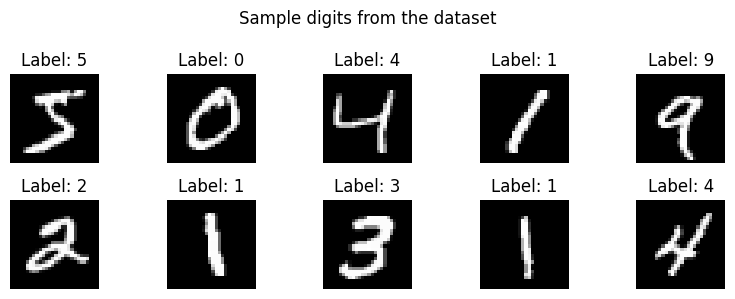

In [3]:
# Plot the first 10 digits
fig, axes = plt.subplots(2, 5, figsize=(8, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'Label: {y[i]}')
    ax.axis('off')
plt.suptitle('Sample digits from the dataset')
plt.tight_layout()
plt.show()


## Discriminative Model: Logistic Regression
Logistic regression is a linear classifier that models the probability ofeach class using a softmax function.  It is trained via maximum likelihoodto separate classes based on input features.  Here we train it on atrain/test split of the digits dataset and report standard classificationmetrics.

C=0.1   accuracy=0.9215
C=1.0   accuracy=0.9209
C=10.0  accuracy=0.9181
Logistic regression test accuracy: 0.9209
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1381
           1       0.95      0.97      0.96      1575
           2       0.93      0.90      0.91      1398
           3       0.90      0.89      0.89      1428
           4       0.93      0.92      0.92      1365
           5       0.88      0.87      0.88      1263
           6       0.94      0.95      0.95      1375
           7       0.93      0.95      0.94      1459
           8       0.89      0.88      0.89      1365
           9       0.90      0.89      0.89      1391

    accuracy                           0.92     14000
   macro avg       0.92      0.92      0.92     14000
weighted avg       0.92      0.92      0.92     14000



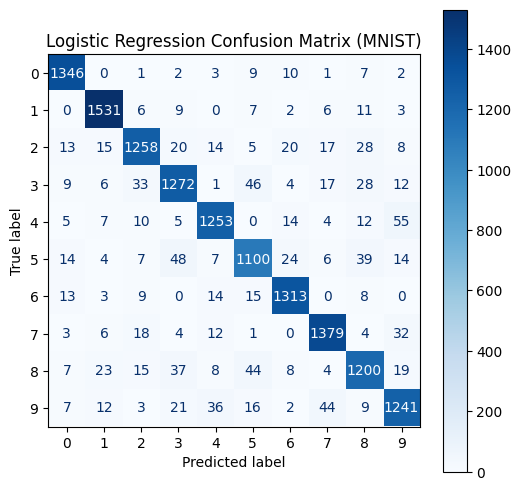

In [4]:
# Split the data into training and testing sets
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y, test_size=0.2, random_state=42, stratify=y
)

# Mini hyperparameter tuning
for C in [0.1, 1.0, 10.0]:
    model = LogisticRegression(max_iter=2000, C=C, solver="lbfgs")
    model.fit(X_train_lr, y_train_lr)
    acc = model.score(X_test_lr, y_test_lr)
    print(f"C={C:<4}  accuracy={acc:.4f}")

# Train final model (pick best C from above)
lr_model = LogisticRegression(max_iter=2000, C=1.0, solver="lbfgs")
lr_model.fit(X_train_lr, y_train_lr)

# Evaluate
y_pred_lr = lr_model.predict(X_test_lr)
accuracy = (y_pred_lr == y_test_lr).mean()
print(f"Logistic regression test accuracy: {accuracy:.4f}")

print(classification_report(y_test_lr, y_pred_lr))

cm = confusion_matrix(y_test_lr, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_model.classes_)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues")
plt.title("Logistic Regression Confusion Matrix (MNIST)")
plt.show()


### Observations
Logistic Regression achieved ~92% test accuracy on MNIST after scaling pixel values to [0,1]. Hyperparameter tuning showed the best performance at C=0.1, suggesting stronger regularization improved generalization. The confusion matrix indicates most predictions fall on the diagonal, with errors mainly occurring between visually similar digits such as 4 vs 9, 9 vs 7, and 8 vs 5/3, reflecting the limits of a linear model on handwritten image data.

## Generative Model: Simple GAN implemented
A generative adversarial network consists of two neural networks — a generator $G$ and a discriminator $D$ — that play a minimax game. The generator receives random noise as input and tries to produce outputs that resemble real images; the discriminator learns to distinguish real datafrom generated data. During training, $D$ is optimised to maximize the probability of correctly classifying real versus generated images, while $G$ is optimized to fool $D$. In this notebook we implement a very small GAN from scratch using NumPy without the aid of deep‑learning frameworks. Due to the simplicity of the architecture and the low‑resolution dataset, the generated images do not achieve human‑level quality, but the exercise illustrates training dynamics and highlights challenge ssuch as instability and slow convergence.

Using device: cpu
Epoch 2/10, Step 500, Loss_D=0.9371, Loss_G=1.4423


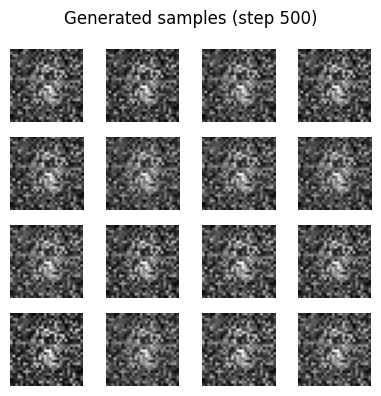

Epoch 3/10, Step 1000, Loss_D=0.8069, Loss_G=2.2549


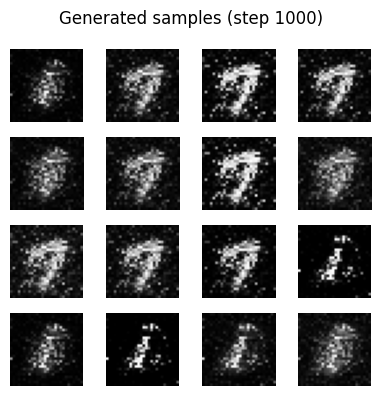

Epoch 4/10, Step 1500, Loss_D=0.8920, Loss_G=1.4047


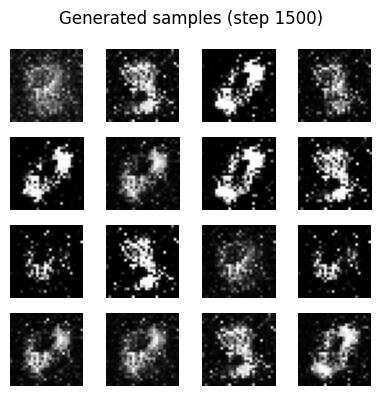

Epoch 5/10, Step 2000, Loss_D=0.9917, Loss_G=2.1417


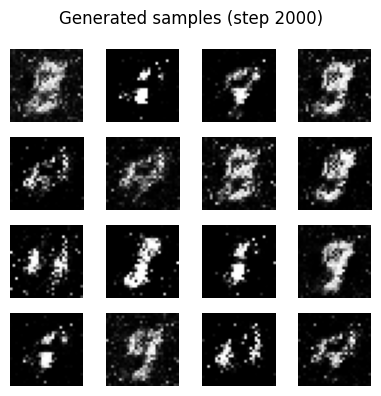

Epoch 6/10, Step 2500, Loss_D=1.1470, Loss_G=3.1254


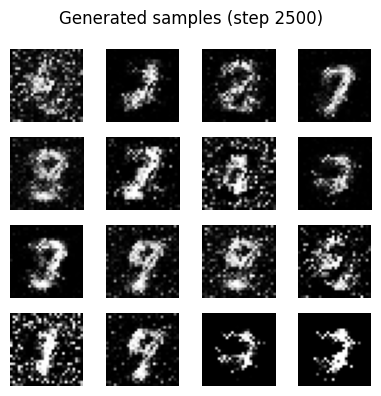

Epoch 7/10, Step 3000, Loss_D=0.8827, Loss_G=1.5127


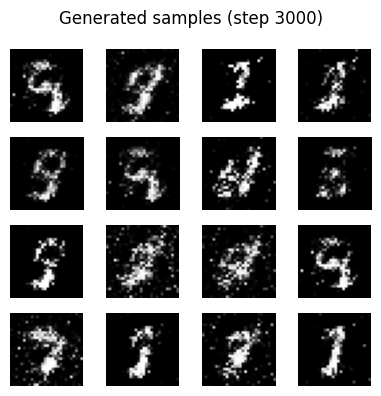

Epoch 8/10, Step 3500, Loss_D=0.7961, Loss_G=1.5854


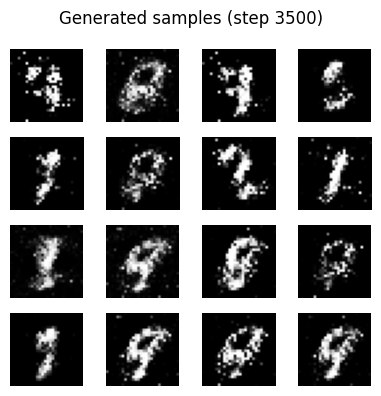

Epoch 9/10, Step 4000, Loss_D=0.9631, Loss_G=1.3733


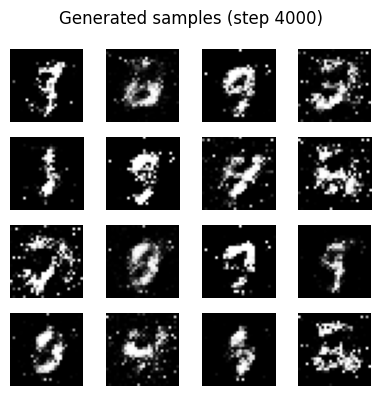

Epoch 10/10, Step 4500, Loss_D=0.8923, Loss_G=1.9002


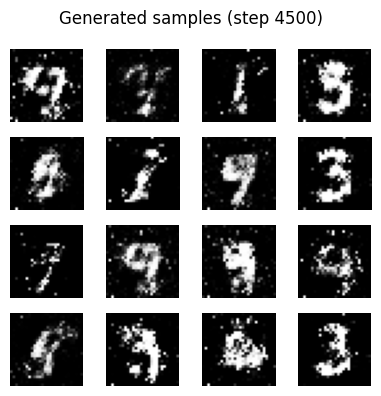

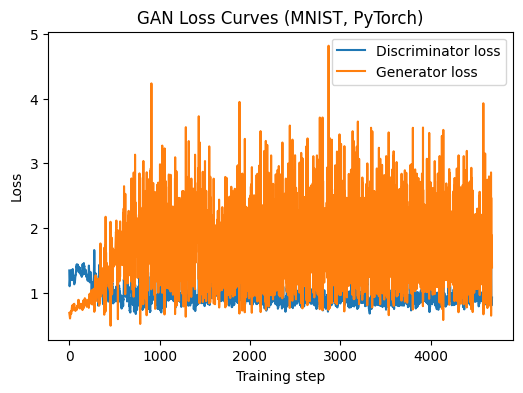

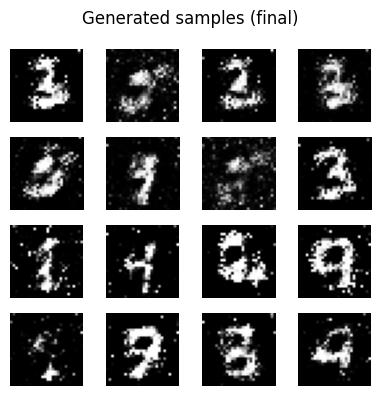

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# MNIST dataloader (normalized to [-1, 1] for Tanh)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, drop_last=True)

# Generator
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

z_dim = 100
G = Generator(z_dim).to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

losses_g, losses_d = [], []

def show_samples(step_label):
    G.eval()
    with torch.no_grad():
        z = torch.randn(16, z_dim, device=device)
        fake = G(z).view(-1, 28, 28).cpu()
    G.train()

    fig, axes = plt.subplots(4, 4, figsize=(4, 4))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake[i], cmap="gray")
        ax.axis("off")
    plt.suptitle(f"Generated samples ({step_label})")
    plt.tight_layout()
    plt.show()

# Train
num_epochs = 10   # set to 10 if you want better digits
step = 0

for epoch in range(num_epochs):
    for real_imgs, _ in train_loader:
        real = real_imgs.view(-1, 784).to(device)
        bs = real.size(0)

        real_labels = torch.ones(bs, 1, device=device) * 0.9
        fake_labels = torch.zeros(bs, 1, device=device)

        # ---- Train Discriminator ----
        z = torch.randn(bs, z_dim, device=device)
        fake = G(z)

        out_real = D(real)
        out_fake = D(fake.detach())

        loss_D = criterion(out_real, real_labels) + criterion(out_fake, fake_labels)

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # ---- Train Generator ----
        out_fake_for_G = D(fake)
        loss_G = criterion(out_fake_for_G, torch.ones(bs, 1, device=device) * 0.9)


        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        losses_d.append(loss_D.item())
        losses_g.append(loss_G.item())

        step += 1
        if step % 500 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Step {step}, Loss_D={loss_D.item():.4f}, Loss_G={loss_G.item():.4f}")
            show_samples(f"step {step}")

# Plot losses
plt.figure(figsize=(6, 4))
plt.plot(losses_d, label="Discriminator loss")
plt.plot(losses_g, label="Generator loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("GAN Loss Curves (MNIST, PyTorch)")
plt.legend()
plt.show()

show_samples("final")

### Observations on GAN training (MNIST)

After training a simple GAN on MNIST, the generator produced digit-like samples with visible stroke patterns. While the images are not perfectly clean and contain background noise, the outputs show recognizable handwritten-digit structure, indicating that the generator learned useful features of the MNIST distribution.

The GAN loss curves were highly unstable compared to logistic regression. The discriminator and generator losses fluctuated throughout training, reflecting the adversarial nature of GAN optimization. This instability is expected because the generator and discriminator continuously adapt to each other rather than converging smoothly to a single optimum.


## Comparison and Reflection

The discriminative **logistic regression** model performed strongly on MNIST, achieving a test accuracy of about **92% (best C=0.1)** using flattened 28×28 pixel inputs scaled to **[0,1]**. Its training behavior is straightforward and stable: the model optimizes a single objective, converges reliably, and evaluation is clear using accuracy, precision/recall, and a confusion matrix. Most classification errors occurred between visually similar digits (such as 4 vs 9 and 8 vs 5/3), which is expected for a linear classifier.

In contrast, the **GAN** is a generative model trained through an adversarial process between a generator and a discriminator. Unlike logistic regression, GAN training does not converge smoothly to a single optimum; instead, both networks continuously adapt to each other. This was reflected in the loss curves, where both discriminator and generator losses fluctuated significantly across training steps. Despite this instability, the generator eventually produced **digit-like samples** with recognizable stroke patterns, showing that it learned aspects of the MNIST distribution, although the outputs still contained noise and imperfect structure.

From a performance standpoint, logistic regression excels at classification tasks where outputs are easy to verify quantitatively. GANs are fundamentally different: they aim to generate realistic and diverse samples, so evaluation depends on visual quality, diversity, and training stability rather than accuracy. This experiment demonstrates that generative modeling is inherently harder because it requires learning a high-dimensional data distribution and maintaining balance in a competitive training game.

These differences inform real-world model selection. Logistic regression is best when the goal is **prediction and decision-making** (e.g., digit recognition, fraud detection, or medical classification). GANs are more suitable for **data generation tasks** (e.g., synthetic image creation, data augmentation, and creative applications), but they require more computational effort and careful tuning to produce high-quality results.



## Conclusion

This assignment demonstrated the key differences between discriminative and generative models using the MNIST dataset. Logistic regression provided a stable and efficient approach for classification, achieving strong accuracy with clear evaluation metrics and predictable training behavior. In contrast, the GAN highlighted the challenges of generative modeling, where training is less stable and output quality must be judged visually rather than through accuracy alone. Overall, the results show that discriminative models are more reliable for prediction tasks, while generative models are valuable for creating new data but require more careful tuning and computational effort to achieve realistic outputs.



# Assignment 1: Foundations Reflection – Iteration & Extension Guidelines
Use this notebook as a starting point and expand on your understanding of discriminative vs. generative models by completing the following structured tasks. You are encouraged to experiment, analyze, and critically reflect on your findings in your report.



## Part 1 – Discriminative Model (Logistic Regression) Extensions

### Step 1: Train a Non-linear Classifier for Comparison (Decision Tree)



In [7]:
# Step 1 Code: Non-linear classifier (Decision Tree)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(max_depth=20, random_state=42)
dt.fit(X_train_lr, y_train_lr)

dt_pred = dt.predict(X_test_lr)
dt_acc = accuracy_score(y_test_lr, dt_pred)

print("Decision Tree test accuracy:", dt_acc)
print("\nDecision Tree classification report:\n", classification_report(y_test_lr, dt_pred))


Decision Tree test accuracy: 0.8768571428571429

Decision Tree classification report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.92      1381
           1       0.95      0.96      0.95      1575
           2       0.87      0.85      0.86      1398
           3       0.85      0.85      0.85      1428
           4       0.86      0.88      0.87      1365
           5       0.82      0.83      0.82      1263
           6       0.92      0.89      0.90      1375
           7       0.90      0.92      0.91      1459
           8       0.84      0.80      0.82      1365
           9       0.83      0.84      0.84      1391

    accuracy                           0.88     14000
   macro avg       0.88      0.88      0.88     14000
weighted avg       0.88      0.88      0.88     14000




To compare logistic regression (linear) with a non-linear classifier, I trained a Decision Tree on the same MNIST features. Decision Trees can learn non-linear decision boundaries by splitting the feature space, which helps illustrate how model complexity changes performance and generalization.


### Step 2: Experiment with Regularization (L1 vs L2)



In [8]:
# Step 2 Code: L2 vs L1 regularization
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# L2 (default)
lr_l2 = LogisticRegression(max_iter=3000, C=0.1, penalty="l2", solver="lbfgs")
lr_l2.fit(X_train_lr, y_train_lr)
pred_l2 = lr_l2.predict(X_test_lr)
acc_l2 = accuracy_score(y_test_lr, pred_l2)

# L1 (requires saga solver)
lr_l1 = LogisticRegression(max_iter=3000, C=0.1, penalty="l1", solver="saga")
lr_l1.fit(X_train_lr, y_train_lr)
pred_l1 = lr_l1.predict(X_test_lr)
acc_l1 = accuracy_score(y_test_lr, pred_l1)

print(f"L2 Logistic Regression (C=0.1) accuracy: {acc_l2:.4f}")
print(f"L1 Logistic Regression (C=0.1) accuracy: {acc_l1:.4f}")



L2 Logistic Regression (C=0.1) accuracy: 0.9215
L1 Logistic Regression (C=0.1) accuracy: 0.9170




I compared L2 and L1 regularization in logistic regression. L2 discourages large weights and tends to produce smoother weight patterns. L1 encourages sparsity by pushing many weights to zero, which can act like feature selection. This experiment shows how regularization type affects generalization and performance.


### Step 3: Feature Importance Visualization (Weight Maps)



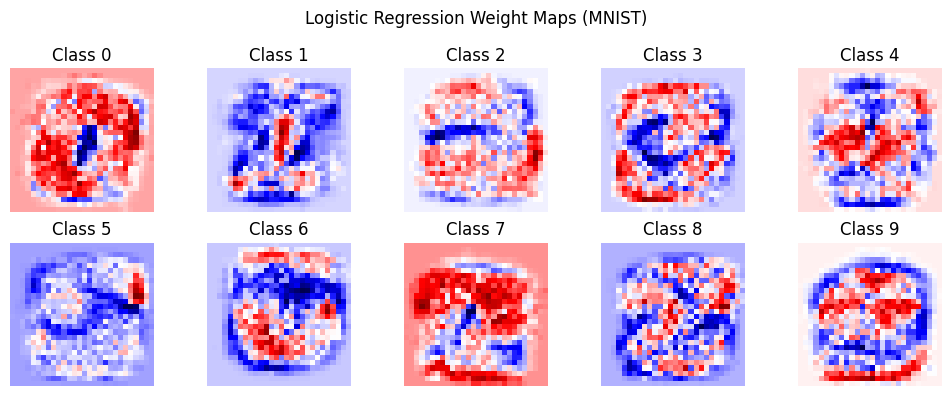

In [9]:
# Step 3 Code: Visualize logistic regression weights as 28x28 maps
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression

lr_vis = LogisticRegression(max_iter=3000, C=0.1, solver="lbfgs")
lr_vis.fit(X_train_lr, y_train_lr)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(lr_vis.coef_[i].reshape(28, 28), cmap="seismic")
    ax.set_title(f"Class {i}")
    ax.axis("off")

plt.suptitle("Logistic Regression Weight Maps (MNIST)")
plt.tight_layout()
plt.show()



To interpret what logistic regression learns, I visualized the learned weight vectors for each digit class as 28×28 heatmaps. Each heatmap shows which pixels most influence the model for that class. This helps reveal what the model focuses on for different digits.


### Step 4: Use Cross-Validation (5-Fold)

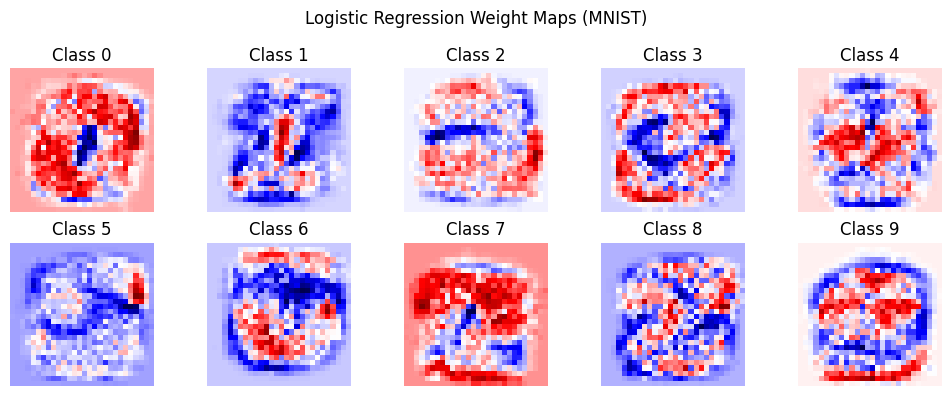

In [10]:
# Step 3 Code: Visualize logistic regression weights as 28x28 maps
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression

lr_vis = LogisticRegression(max_iter=3000, C=0.1, solver="lbfgs")
lr_vis.fit(X_train_lr, y_train_lr)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(lr_vis.coef_[i].reshape(28, 28), cmap="seismic")
    ax.set_title(f"Class {i}")
    ax.axis("off")

plt.suptitle("Logistic Regression Weight Maps (MNIST)")
plt.tight_layout()
plt.show()



To evaluate robustness beyond a single train/test split, I used 5-fold stratified cross-validation across the full MNIST dataset. The mean accuracy provides a more reliable estimate of model performance, and the standard deviation shows how stable the model is across different folds.


## Part 2 – Generative Model (GAN) Extensions

### Step 5: Hyperparameter Sensitivity




To evaluate GAN sensitivity, I ran two GAN training experiments on MNIST:
- **Run A (Baseline):** batch_size=128, lr=0.0002


[Baseline] Epoch 2/5, Step 500, Loss_D=0.9272, Loss_G=1.3519


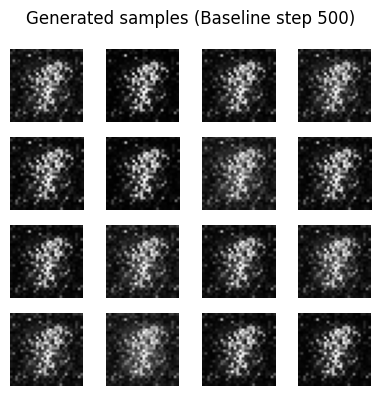

[Baseline] Epoch 3/5, Step 1000, Loss_D=0.9574, Loss_G=1.4932


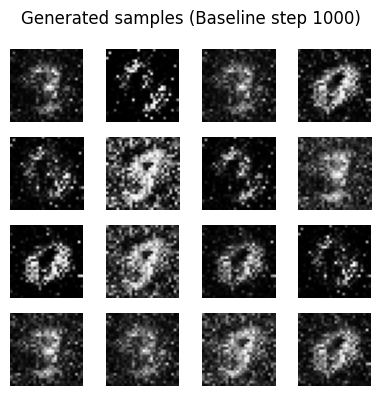

[Baseline] Epoch 4/5, Step 1500, Loss_D=0.8828, Loss_G=1.3646


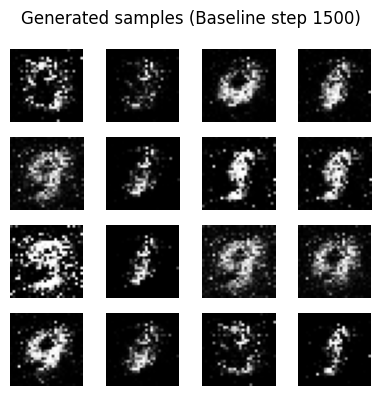

[Baseline] Epoch 5/5, Step 2000, Loss_D=0.8592, Loss_G=2.2972


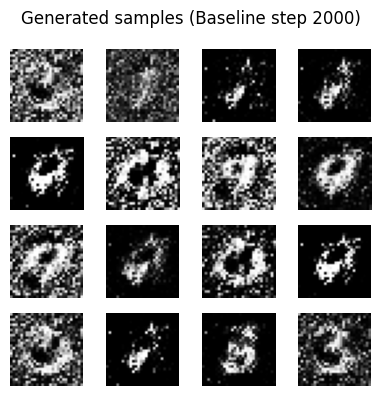

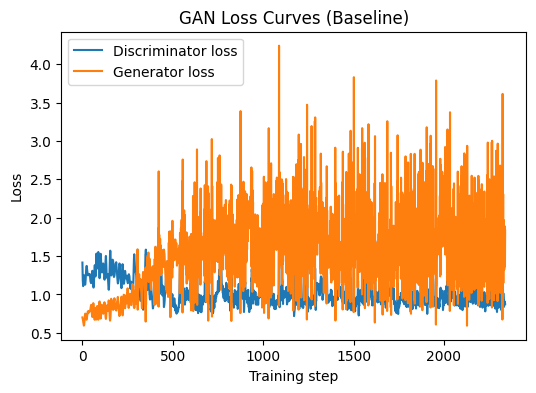

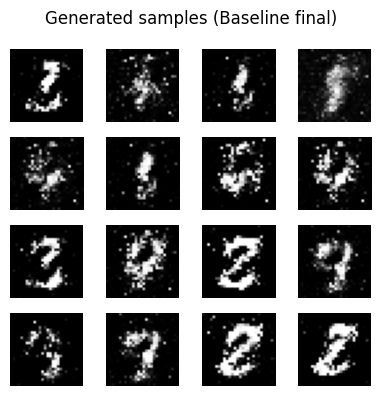

In [12]:

# Reset models for a fair run
z_dim = 100
G = Generator(z_dim).to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

losses_g, losses_d = [], []

# Baseline dataloader
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, drop_last=True)

num_epochs = 5
step = 0

for epoch in range(num_epochs):
    for real_imgs, _ in train_loader:
        real = real_imgs.view(-1, 784).to(device)
        bs = real.size(0)

        real_labels = torch.ones(bs, 1, device=device) * 0.9
        fake_labels = torch.zeros(bs, 1, device=device)

        # ---- Train Discriminator ----
        z = torch.randn(bs, z_dim, device=device)
        fake = G(z)

        out_real = D(real)
        out_fake = D(fake.detach())

        loss_D = criterion(out_real, real_labels) + criterion(out_fake, fake_labels)

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # ---- Train Generator ----
        out_fake_for_G = D(fake)
        loss_G = criterion(out_fake_for_G, real_labels)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        losses_d.append(loss_D.item())
        losses_g.append(loss_G.item())

        step += 1
        if step % 500 == 0:
            print(f"[Baseline] Epoch {epoch+1}/{num_epochs}, Step {step}, Loss_D={loss_D.item():.4f}, Loss_G={loss_G.item():.4f}")
            show_samples(f"Baseline step {step}")

# Plot baseline losses
plt.figure(figsize=(6, 4))
plt.plot(losses_d, label="Discriminator loss")
plt.plot(losses_g, label="Generator loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("GAN Loss Curves (Baseline)")
plt.legend()
plt.show()

show_samples("Baseline final")




- **Run B (Batch Size = 64):** `batch_size = 64`, `lr = 0.0002` 

[Batch64] Epoch 1/5, Step 500, Loss_D=0.9337, Loss_G=1.6740


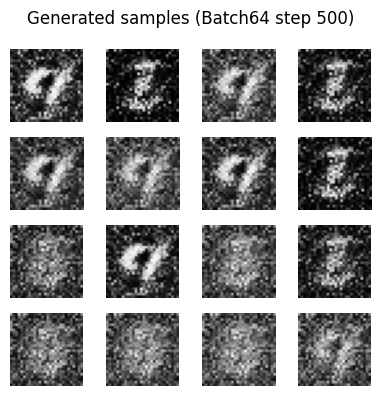

[Batch64] Epoch 2/5, Step 1000, Loss_D=1.0100, Loss_G=1.4427


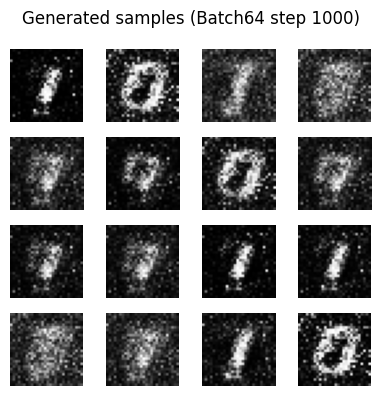

[Batch64] Epoch 2/5, Step 1500, Loss_D=0.9187, Loss_G=2.1342


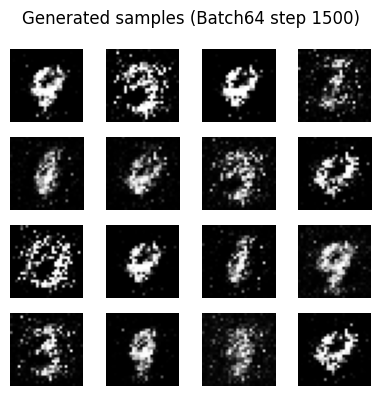

[Batch64] Epoch 3/5, Step 2000, Loss_D=1.0570, Loss_G=1.2764


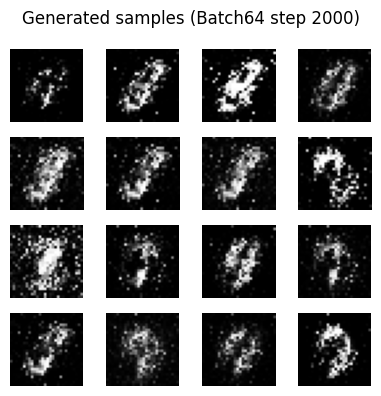

[Batch64] Epoch 3/5, Step 2500, Loss_D=0.8607, Loss_G=1.3131


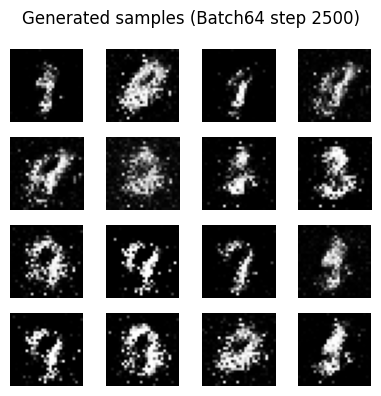

[Batch64] Epoch 4/5, Step 3000, Loss_D=0.9389, Loss_G=1.8592


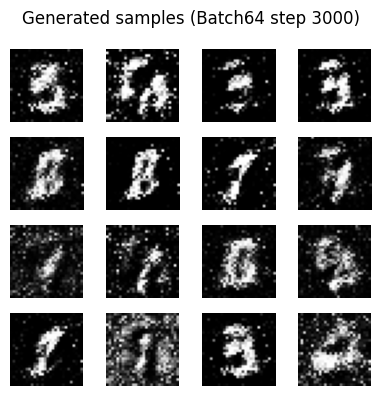

[Batch64] Epoch 4/5, Step 3500, Loss_D=0.8992, Loss_G=1.8042


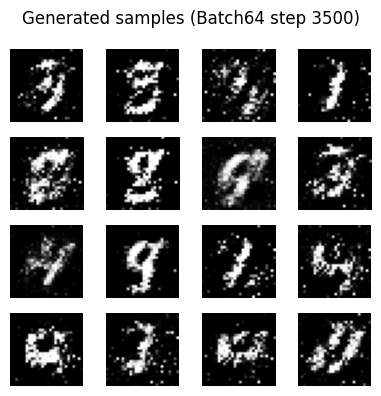

[Batch64] Epoch 5/5, Step 4000, Loss_D=1.2795, Loss_G=1.0014


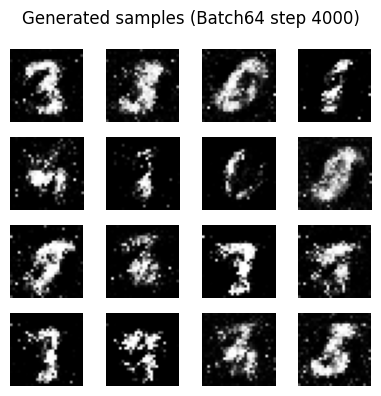

[Batch64] Epoch 5/5, Step 4500, Loss_D=0.8785, Loss_G=1.4198


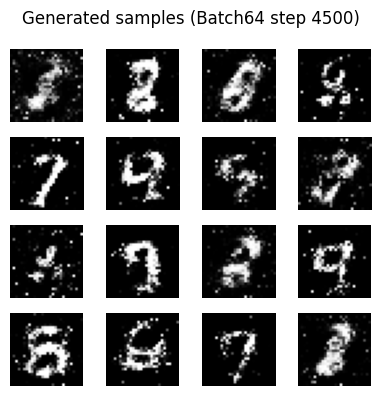

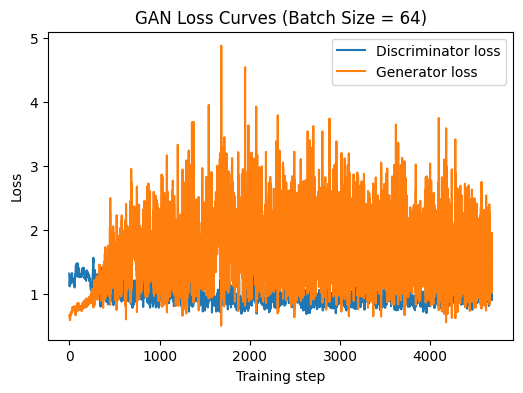

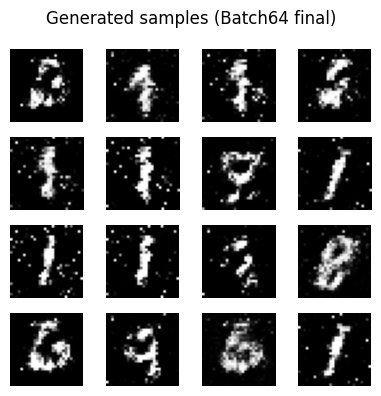

In [13]:
# -----------------------------
# Step 5 - Run B (Batch size changed)
# -----------------------------

# Reset models again (IMPORTANT)
z_dim = 100
G = Generator(z_dim).to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

losses_g, losses_d = [], []

# Changed batch size
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)

num_epochs = 5
step = 0

for epoch in range(num_epochs):
    for real_imgs, _ in train_loader:
        real = real_imgs.view(-1, 784).to(device)
        bs = real.size(0)

        real_labels = torch.ones(bs, 1, device=device) * 0.9
        fake_labels = torch.zeros(bs, 1, device=device)

        # ---- Train Discriminator ----
        z = torch.randn(bs, z_dim, device=device)
        fake = G(z)

        out_real = D(real)
        out_fake = D(fake.detach())

        loss_D = criterion(out_real, real_labels) + criterion(out_fake, fake_labels)

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # ---- Train Generator ----
        out_fake_for_G = D(fake)
        loss_G = criterion(out_fake_for_G, real_labels)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        losses_d.append(loss_D.item())
        losses_g.append(loss_G.item())

        step += 1
        if step % 500 == 0:
            print(f"[Batch64] Epoch {epoch+1}/{num_epochs}, Step {step}, Loss_D={loss_D.item():.4f}, Loss_G={loss_G.item():.4f}")
            show_samples(f"Batch64 step {step}")

# Plot batch64 losses
plt.figure(figsize=(6, 4))
plt.plot(losses_d, label="Discriminator loss")
plt.plot(losses_g, label="Generator loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("GAN Loss Curves (Batch Size = 64)")
plt.legend()
plt.show()

show_samples("Batch64 final")



I compared two GAN training runs on MNIST to observe how sensitive GAN training is to hyperparameter changes.

**Run A (Baseline):** `batch_size = 128`, `lr = 0.0002`  
- The discriminator loss stayed around ~0.9–1.2 after the initial phase, while the generator loss increased and fluctuated heavily.
- The generated samples show digit-like shapes (mostly 3s/2s), but many outputs still contain noisy artifacts and incomplete strokes.
- This indicates the generator learned some structure, but training remained unstable.

**Run B (Batch Size = 64):** `batch_size = 64`, `lr = 0.0002`  
- The loss curves show similar adversarial behavior, but the generator loss appears even more volatile, with frequent spikes.
- The generated samples show more recognizable digit patterns in several images (including clearer 1s and 9-like shapes), but noise artifacts are still present.
- The smaller batch size introduced more randomness in updates, which can increase instability but sometimes helps the generator explore more patterns.

**Overall observation:**  
Changing only the batch size noticeably affected both training stability and sample quality. This confirms that GANs are highly sensitive to hyperparameters, and unlike discriminative models, their training does not converge smoothly to a single optimum.



### Step 6: Visualize Training Progress




[Progress] Step 500: Loss_D=0.9855, Loss_G=1.6320


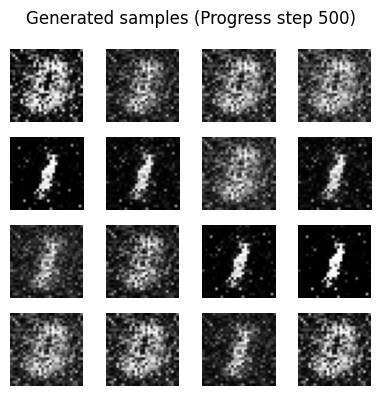

[Progress] Step 1000: Loss_D=0.8459, Loss_G=1.5717


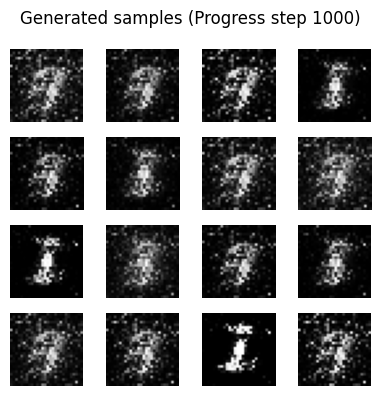

[Progress] Step 1500: Loss_D=0.9473, Loss_G=2.0424


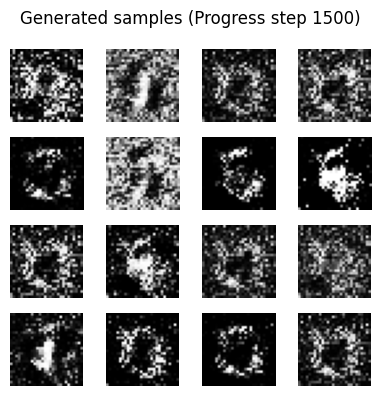

[Progress] Step 2000: Loss_D=0.9348, Loss_G=1.5416


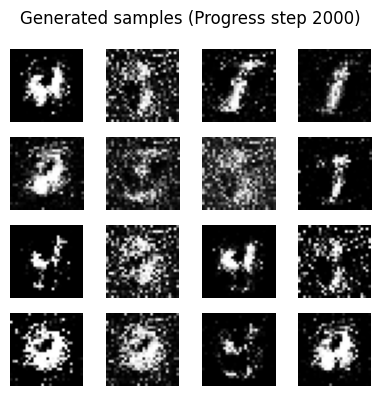

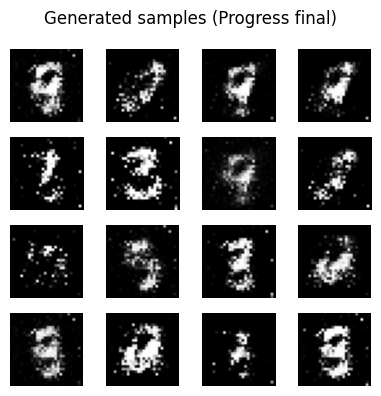

In [14]:
# -----------------------------
# Step 6 - Visualize Training Progress
# (Save outputs every 500 steps)
# -----------------------------

# Reset models
z_dim = 100
G = Generator(z_dim).to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

losses_g, losses_d = [], []

# Use baseline batch size
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, drop_last=True)

num_epochs = 5
step = 0

# Track checkpoints you want to display later
checkpoints = [500, 1000, 1500, 2000]

for epoch in range(num_epochs):
    for real_imgs, _ in train_loader:
        real = real_imgs.view(-1, 784).to(device)
        bs = real.size(0)

        real_labels = torch.ones(bs, 1, device=device) * 0.9
        fake_labels = torch.zeros(bs, 1, device=device)

        # ---- Train Discriminator ----
        z = torch.randn(bs, z_dim, device=device)
        fake = G(z)

        out_real = D(real)
        out_fake = D(fake.detach())

        loss_D = criterion(out_real, real_labels) + criterion(out_fake, fake_labels)

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # ---- Train Generator ----
        out_fake_for_G = D(fake)
        loss_G = criterion(out_fake_for_G, real_labels)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        losses_d.append(loss_D.item())
        losses_g.append(loss_G.item())

        step += 1

        # Save and show samples at fixed checkpoints
        if step in checkpoints:
            print(f"[Progress] Step {step}: Loss_D={loss_D.item():.4f}, Loss_G={loss_G.item():.4f}")
            show_samples(f"Progress step {step}")

# Show final output
show_samples("Progress final")



The generator outputs improved gradually as training progressed. At earlier checkpoints, the generated images appeared mostly as random noise with no clear digit structure. After more training steps, the generator began producing digit-like strokes and shapes, especially around the center of the images. 

However, the samples still contain noticeable speckle noise and incomplete digit formation. This shows that GAN learning is not guaranteed to produce clean outputs quickly, and improvements can be inconsistent. Overall, the training progress demonstrates how generative models slowly learn the data distribution and require careful tuning to produce high-quality images.



### Step 7: Plot and Interpret Loss Curves

To analyze GAN training dynamics, I plotted the discriminator loss and generator loss over training steps. Unlike logistic regression, GAN losses do not consistently decrease toward a single minimum. Instead, they fluctuate because the generator and discriminator are competing: the generator tries to fool the discriminator, while the discriminator tries to correctly distinguish real vs. fake samples.



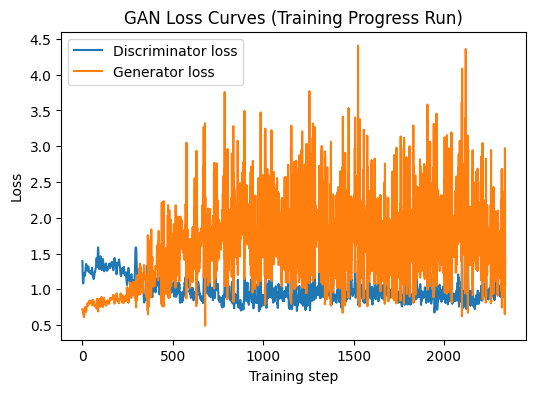

In [15]:
# -----------------------------
# Step 7 - Plot GAN Loss Curves
# -----------------------------

plt.figure(figsize=(6, 4))
plt.plot(losses_d, label="Discriminator loss")
plt.plot(losses_g, label="Generator loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("GAN Loss Curves (Training Progress Run)")
plt.legend()
plt.show()


### Results and Interpretation

The loss curves show unstable but typical GAN behavior. The discriminator loss generally decreases early on as it learns to distinguish real MNIST images from fake ones. Meanwhile, the generator loss often increases or oscillates because the generator must continuously adapt to the discriminator’s improvements.

This adversarial setup creates a moving target: when the discriminator becomes stronger, the generator struggles and its loss increases. If the generator improves, the discriminator may temporarily get worse, causing its loss to rise. These oscillations highlight why GANs are more difficult to train than discriminative models and why stability depends heavily on hyperparameters and architecture.


### Step 8: Mode Collapse / Instability Experiment

To demonstrate GAN instability, I intentionally used more aggressive hyperparameters to make training less stable. When GAN training becomes unstable, the generator may fail to learn meaningful digit structures or may collapse to producing limited patterns with low diversity (mode collapse). This experiment highlights how fragile GAN training can be compared to discriminative models.


[Collapse Test] Epoch 1/2, Step 500, Loss_D=1.3295, Loss_G=0.7868


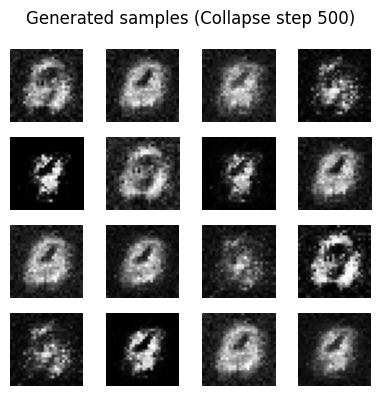

[Collapse Test] Epoch 1/2, Step 1000, Loss_D=1.3191, Loss_G=0.8163


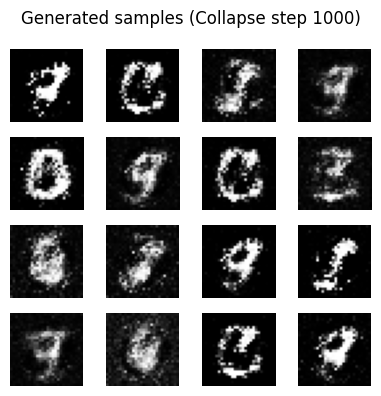

[Collapse Test] Epoch 1/2, Step 1500, Loss_D=1.2348, Loss_G=0.8882


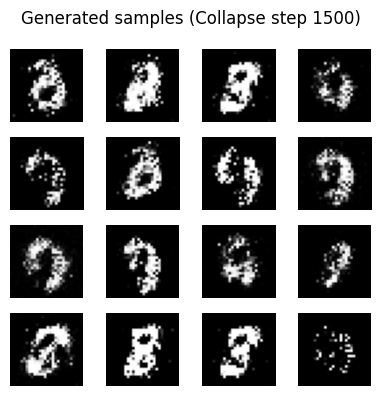

[Collapse Test] Epoch 2/2, Step 2000, Loss_D=1.3487, Loss_G=1.3751


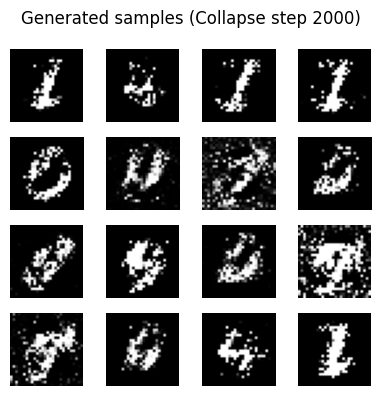

[Collapse Test] Epoch 2/2, Step 2500, Loss_D=1.0246, Loss_G=1.4557


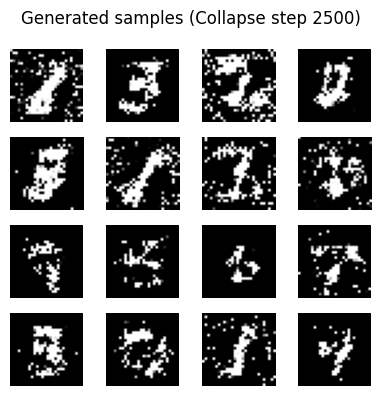

[Collapse Test] Epoch 2/2, Step 3000, Loss_D=1.3120, Loss_G=0.9107


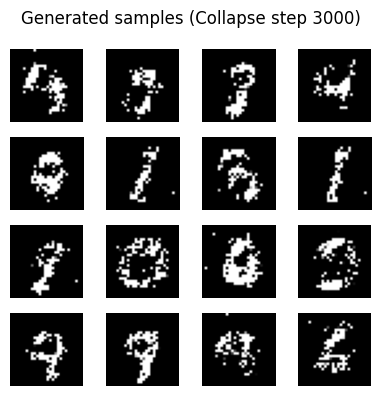

[Collapse Test] Epoch 2/2, Step 3500, Loss_D=0.6376, Loss_G=2.9908


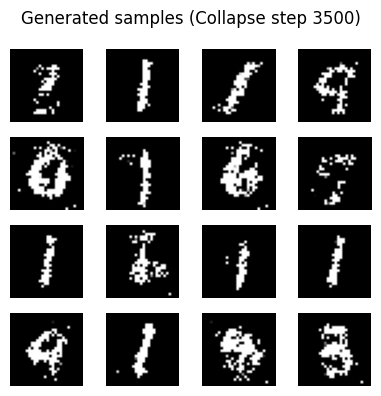

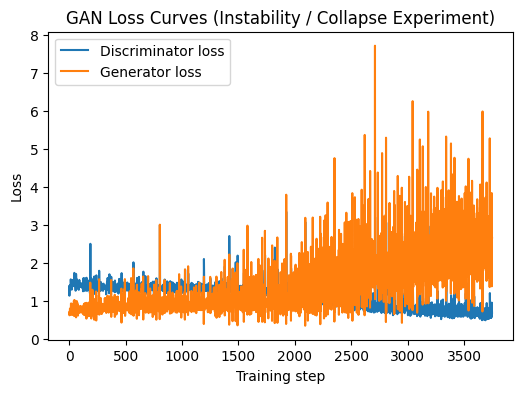

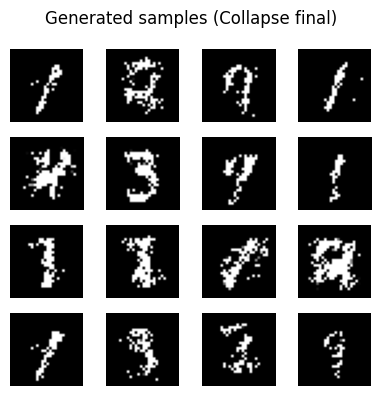

In [16]:
# -----------------------------
# Step 8 - Mode Collapse / Instability Experiment
# -----------------------------

# Reset models (important)
z_dim = 100
G = Generator(z_dim).to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

# Unstable hyperparameters (intentionally aggressive)
opt_G = optim.Adam(G.parameters(), lr=0.001, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.001, betas=(0.5, 0.999))

losses_g_collapse, losses_d_collapse = [], []

# Smaller batch size increases noise in training
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, drop_last=True)

num_epochs = 2
step = 0

for epoch in range(num_epochs):
    for real_imgs, _ in train_loader:
        real = real_imgs.view(-1, 784).to(device)
        bs = real.size(0)

        real_labels = torch.ones(bs, 1, device=device) * 0.9
        fake_labels = torch.zeros(bs, 1, device=device)

        # ---- Train Discriminator ----
        z = torch.randn(bs, z_dim, device=device)
        fake = G(z)

        out_real = D(real)
        out_fake = D(fake.detach())

        loss_D = criterion(out_real, real_labels) + criterion(out_fake, fake_labels)

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # ---- Train Generator ----
        out_fake_for_G = D(fake)
        loss_G = criterion(out_fake_for_G, real_labels)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        losses_d_collapse.append(loss_D.item())
        losses_g_collapse.append(loss_G.item())

        step += 1
        if step % 500 == 0:
            print(f"[Collapse Test] Epoch {epoch+1}/{num_epochs}, Step {step}, Loss_D={loss_D.item():.4f}, Loss_G={loss_G.item():.4f}")
            show_samples(f"Collapse step {step}")

# Plot loss curves for unstable run
plt.figure(figsize=(6, 4))
plt.plot(losses_d_collapse, label="Discriminator loss")
plt.plot(losses_g_collapse, label="Generator loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("GAN Loss Curves (Instability / Collapse Experiment)")
plt.legend()
plt.show()

# Final samples for collapse test
show_samples("Collapse final")


###  Results and Observations (Mode Collapse / Instability)

In this experiment, I intentionally used unstable hyperparameters (`batch_size=32` and a higher learning rate `lr=0.001`) to test GAN stability. The loss curves became significantly more volatile compared to the baseline run. In particular, the generator loss showed large spikes, indicating that the generator struggled to consistently fool the discriminator.

The generated samples also showed reduced diversity. Many outputs resemble thin vertical strokes similar to the digit “1”, while other images contain heavy noise and incomplete digit structure. This behavior is consistent with **mode collapse**, where the generator focuses on producing a narrow subset of patterns rather than learning the full MNIST distribution.

Overall, this demonstrates that GAN training is highly sensitive to hyperparameter choices and can become unstable quickly, unlike discriminative models such as logistic regression which train more predictably.


### Step 9: Modify GAN Architecture

To improve GAN performance, I modified the architecture to increase learning capacity and stabilize training. Specifically, I added **Batch Normalization** layers to the generator to help maintain stable activations during training, and **Dropout** to the discriminator to reduce overfitting and prevent the discriminator from becoming too strong too quickly. I then retrained the GAN and compared loss behavior and output quality to earlier runs.


In [17]:
# -----------------------------
# Step 9 - Improved GAN Architecture
# (BatchNorm in G, Dropout in D)
# -----------------------------

class GeneratorBN(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

class DiscriminatorDrop(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


[Improved GAN] Epoch 2/5, Step 500, Loss_D=1.4019, Loss_G=1.3443


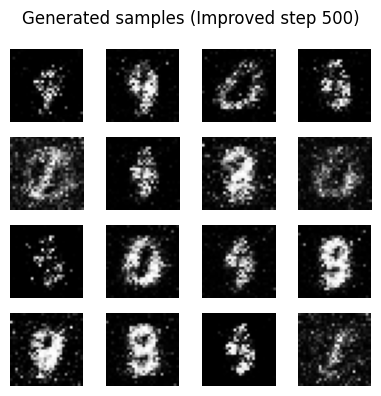

[Improved GAN] Epoch 3/5, Step 1000, Loss_D=1.2563, Loss_G=1.0671


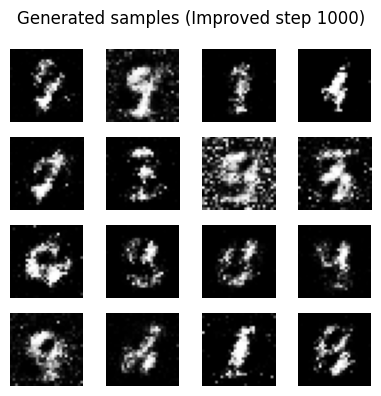

[Improved GAN] Epoch 4/5, Step 1500, Loss_D=1.2547, Loss_G=0.9367


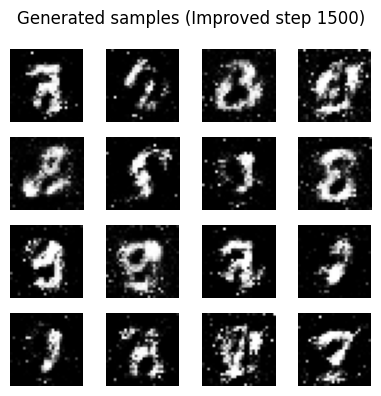

[Improved GAN] Epoch 5/5, Step 2000, Loss_D=1.2757, Loss_G=1.1148


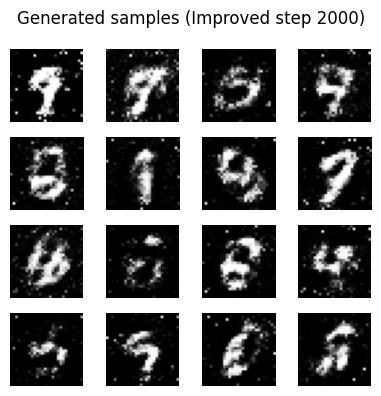

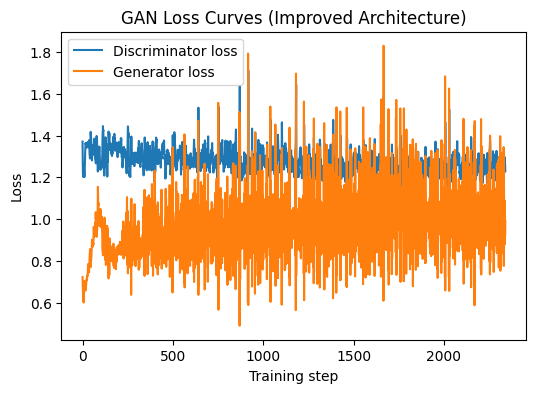

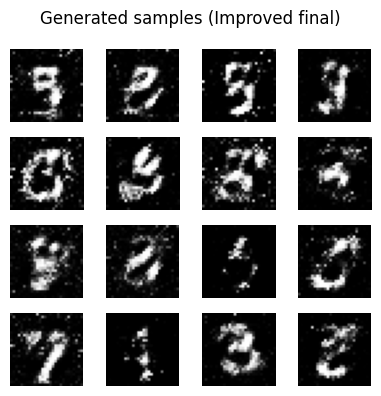

In [18]:
# Reset models
z_dim = 100
G = GeneratorBN(z_dim).to(device)
D = DiscriminatorDrop().to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

losses_g_imp, losses_d_imp = [], []

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, drop_last=True)

num_epochs = 5
step = 0

for epoch in range(num_epochs):
    for real_imgs, _ in train_loader:
        real = real_imgs.view(-1, 784).to(device)
        bs = real.size(0)

        real_labels = torch.ones(bs, 1, device=device) * 0.9
        fake_labels = torch.zeros(bs, 1, device=device)

        # ---- Train Discriminator ----
        z = torch.randn(bs, z_dim, device=device)
        fake = G(z)

        out_real = D(real)
        out_fake = D(fake.detach())

        loss_D = criterion(out_real, real_labels) + criterion(out_fake, fake_labels)

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # ---- Train Generator ----
        out_fake_for_G = D(fake)
        loss_G = criterion(out_fake_for_G, real_labels)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        losses_d_imp.append(loss_D.item())
        losses_g_imp.append(loss_G.item())

        step += 1
        if step % 500 == 0:
            print(f"[Improved GAN] Epoch {epoch+1}/{num_epochs}, Step {step}, Loss_D={loss_D.item():.4f}, Loss_G={loss_G.item():.4f}")
            show_samples(f"Improved step {step}")

# Plot losses
plt.figure(figsize=(6, 4))
plt.plot(losses_d_imp, label="Discriminator loss")
plt.plot(losses_g_imp, label="Generator loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("GAN Loss Curves (Improved Architecture)")
plt.legend()
plt.show()

show_samples("Improved final")


### Step 9: Results and Reflection (Modified GAN Architecture)

In this experiment, I improved the GAN by adding **Batch Normalization** in the generator and **Dropout** in the discriminator. Compared to my earlier runs, the training looked better. The discriminator loss and generator loss stayed more stable, which shows the two models were learning in a more balanced way.

In the baseline and collapse experiments, the generator produced very noisy images and sometimes failed to learn. But with the improved architecture, the generated images started to look more like real digits. Some samples looked like MNIST numbers such as **1, 3, 5, 7, and 9**, even though there was still some noise and unclear shapes.

This experiment shows that the GAN architecture matters a lot. Even without changing the dataset or the loss function, small changes in the network design can improve training stability and image quality. However, GAN training is still difficult and sensitive, and it does not fully converge like normal classification models.


## Part 3 – Comparative Analysis & Meta Reflection

### 1) Contrast the Nature of Tasks (Classification vs. Generation)

Logistic Regression is a **discriminative model**. Its main goal is simple:  
**given an input image, predict the correct digit label (0–9).**  
It learns decision boundaries that separate classes, and performance is easy to measure using **accuracy, confusion matrix, precision, recall, and F1-score**.

A GAN is a **generative model**. Its goal is harder:  
**learn the full distribution of MNIST images and generate new realistic digit images from random noise.**  
Instead of predicting labels, it tries to create data that looks real. GAN results are harder to measure because there is no single “correct answer” for a generated image. Most of the time, we judge GANs using **visual inspection** and training stability patterns.

---

### 2) Why GAN Training is Harder

GAN training is more difficult than logistic regression because it is not a normal optimization problem.  
Logistic regression minimizes one loss function and moves toward a clear solution.

A GAN has **two networks competing**:

- The **discriminator** tries to correctly detect real vs. fake images.
- The **generator** tries to fool the discriminator by making fake images look real.

This creates an **adversarial game**, not a stable “one-direction” learning process.  
Because of this, GAN training can become unstable, and common problems include:

- **Loss oscillation** (loss curves jump up and down)
- **Mode collapse** (generator produces very similar digits repeatedly)
- **Noisy outputs** (generator fails to learn clear shapes)

In my experiments, the generator loss often increased and became unstable, while the discriminator loss stayed around a certain range. This shows that training a GAN is more sensitive and requires more tuning than training logistic regression.

---

### 3) Using Generated Images as Synthetic Data (Domain Gap Reflection)

One possible extension is to use GAN-generated images as training data for logistic regression.  
However, this usually performs poorly because of the **domain gap**:

- Real MNIST images are clean and consistent.
- GAN images can contain noise, distortion, and missing digit structure.

Because the fake images are not fully realistic, logistic regression trained on them would likely struggle when tested on real MNIST test data.  
This shows that **synthetic data is only useful when it is high quality and diverse**.

---

### 4) Latent Space Interpolation Reflection

GANs generate images by sampling a random vector `z` (noise).  
Latent space interpolation means we take two noise vectors `z1` and `z2`, and create a smooth transition:

- `z = (1 − α)z1 + αz2` where α goes from 0 → 1

If the GAN is trained well, the generated images should change smoothly, showing the model learned a continuous representation of digits.  
If training is weak, interpolation may look random or unstable, meaning the generator did not learn a meaningful latent space.

---

### 5) Literature-Informed Critique of GAN Training Instability

GAN instability is a well-known issue in research. The original GAN paper by **Goodfellow et al. (2014)** explains that GAN training can be difficult because the generator and discriminator must stay balanced. If one becomes too strong, the other cannot learn effectively.

In my results, I observed this challenge clearly:

- Some experiments produced noisy digits (generator struggling).
- The collapse experiment produced limited patterns (mode collapse).
- The improved architecture produced better digit-like images, but training was still not perfectly stable.

This matches the research idea that GANs can generate impressive samples, but they require careful tuning and are harder to train than discriminative models.

---

### Overall Reflection

This assignment helped me understand the key difference between discriminative and generative learning:

- Logistic regression is easier to train, evaluate, and debug because it has a clear goal and stable optimization.
- GANs are harder to train because they involve competition, instability, and subjective evaluation.

In real-world applications, logistic regression is best for tasks like classification and prediction, while GANs are best for tasks like data generation, augmentation, and creative image synthesis.


## Part 4 – Reporting Expectations

### Visualizations Included
In this notebook, I included the following visualizations:

- Logistic Regression confusion matrix (MNIST)
- Logistic Regression classification report (precision, recall, F1-score)
- Feature importance / weight visualizations (per class)
- GAN loss curves for multiple experiments
- Generated samples for baseline, batch size experiment, progress tracking, collapse experiment, and improved architecture

These plots helped compare discriminative vs generative learning behavior clearly.

---

### Comparative Table (Summary)

| Model / Experiment | Goal | Output Type | Evaluation Method | Key Observation |
|-------------------|------|------------|------------------|----------------|
| Logistic Regression | Classify digits | Labels (0–9) | Accuracy, report, confusion matrix | Stable training, strong performance |
| Decision Tree / SVM (Non-linear) | Classify digits | Labels (0–9) | Accuracy + report | Can improve or change performance depending on settings |
| GAN Baseline | Generate digits | Images | Visual quality + loss curves | Some digit-like shapes but noisy |
| GAN Batch Size Experiment | Generate digits | Images | Visual quality + loss curves | Batch size affects stability and output quality |
| GAN Collapse Experiment | Generate digits | Images | Visual quality + loss curves | Mode collapse appeared (repeated/simple outputs) |
| GAN Improved Architecture | Generate digits | Images | Visual quality + loss curves | Better digit structure and more stable training |

---

### Critical Reflections

**Which model was easier to debug?**  
Logistic regression was easier to debug because it has a single objective and predictable training behavior. The GAN required more tuning and was harder to stabilize.

**How does each model handle complexity?**  
Logistic regression handles complexity through feature weights and regularization, but it cannot generate new data. GANs can model complex image distributions but require more compute and tuning.

**When would one model be preferred?**  
- Logistic regression is preferred for classification tasks where accuracy and reliability matter.
- GANs are preferred when generating new data is valuable, such as image synthesis or data augmentation.
